In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [3]:
df = pd.read_csv("stock_data.csv",
                 parse_dates=True,
                 index_col="Date")
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


In [29]:
df.tail()

,Open,High,Low,Close,Volume,Name,high_smoothed,high_diff
Date,,,,,,,,
2017-12-22,71.42,71.87,71.22,71.58,10979165,AABA,66.082917,-0.30
2017-12-26,70.94,71.39,69.63,69.86,8542802,AABA,66.217833,-0.48
2017-12-27,69.77,70.49,69.69,70.06,6345124,AABA,66.347667,-0.90
2017-12-28,70.12,70.32,69.51,69.82,7556877,AABA,66.475500,-0.17
2017-12-29,69.79,70.13,69.43,69.85,6613070,AABA,66.598667,-0.19


In [18]:
df.drop(columns='Unnamed: 0', inplace =True)
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


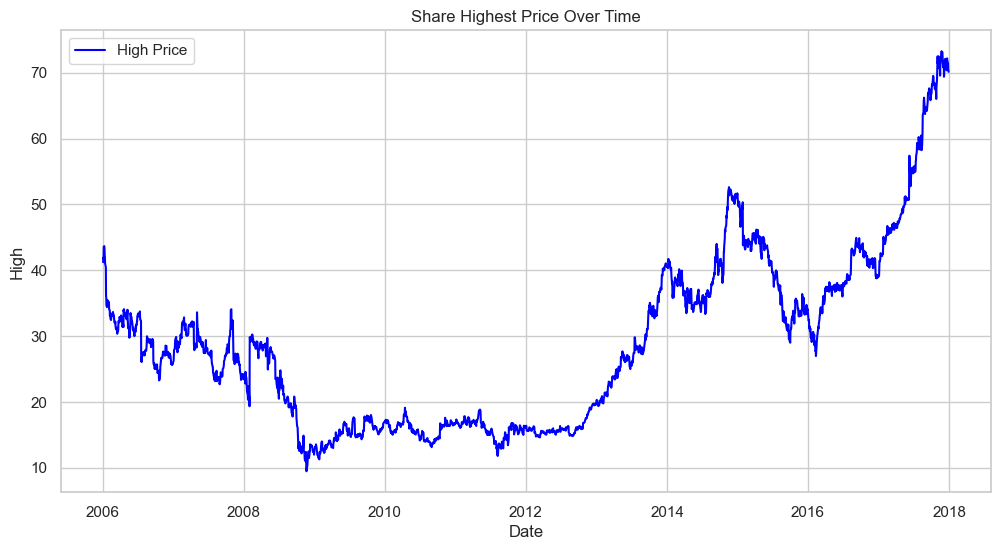

In [19]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='High', label='High Price', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

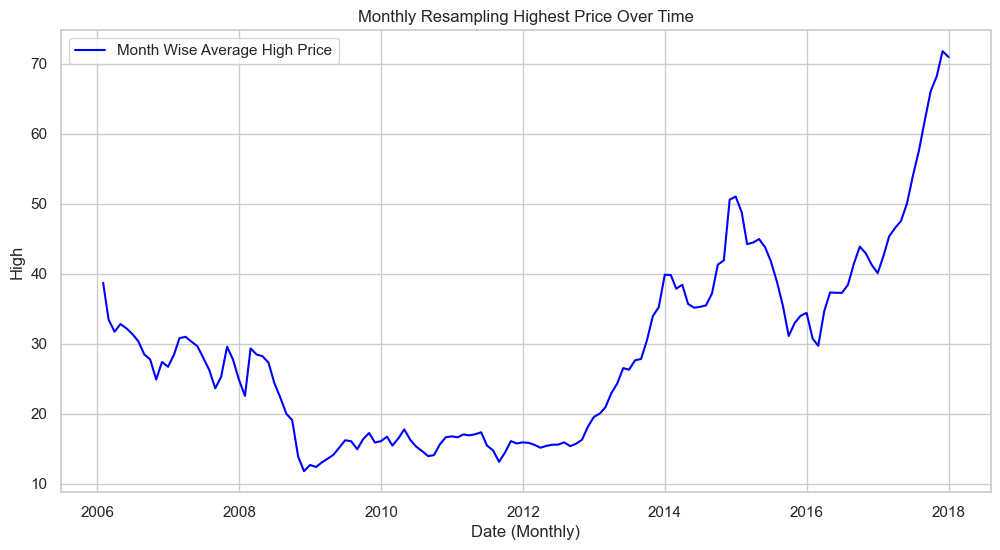

In [8]:
df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', label='Month Wise Average High Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

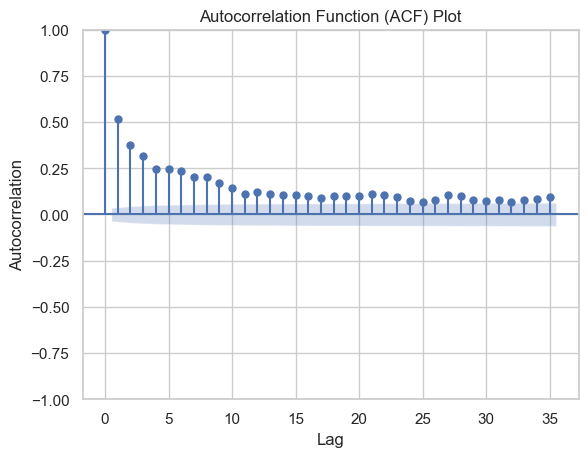

In [21]:
if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['Volume'])
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 0.7671404880535937
p-value: 0.9910868050318213
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


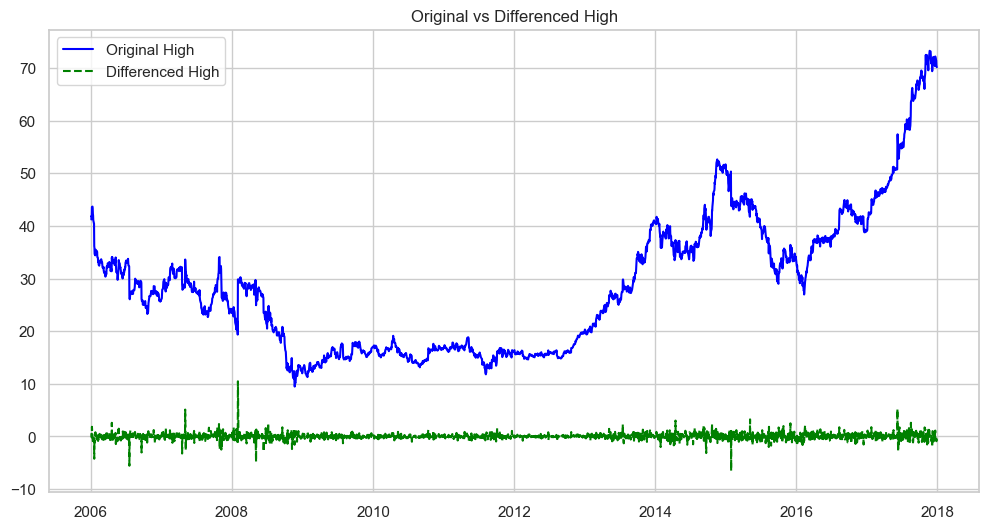

In [25]:
df['high_diff'] = df['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

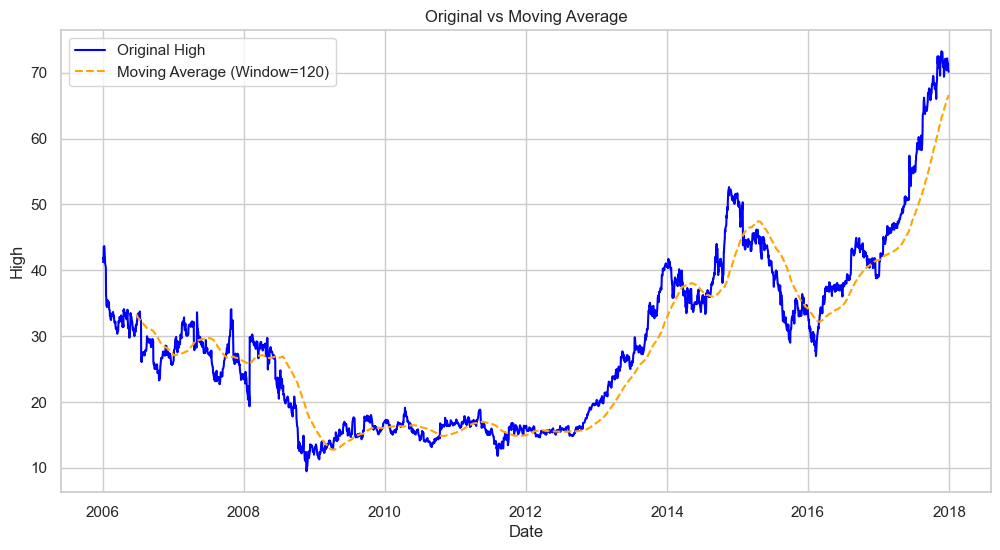

In [23]:
window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

In [26]:
df_combined = pd.concat([df['High'], df['high_diff']], axis=1)

print(df_combined.head())

             High  high_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [27]:
df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: high_diff, dtype: float64

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.148367478343259
p-value: 1.5912766134147782e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


## Classwork

Training data size: 2929 days
Testing data size: 90 days

Running auto_arima to find the optimal model parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=7587.990, Time=0.12 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=6751.113, Time=0.09 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.68 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=7585.991, Time=0.04 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=6431.858, Time=0.11 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=6219.967, Time=0.15 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=6099.877, Time=0.18 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=6011.553, Time=0.28 sec
 ARIMA(6,2,0)(0,0,0)[0] intercept   : AIC=5944.352, Time=0.34 sec
 ARIMA(7,2,0)(0,0,0)[0] intercept   : AIC=5899.228, Time=0.57 sec
 ARIMA(8,2,0)(0,0,0)[0] intercept   : AIC=5842.081, Time=0.65 sec
 ARIMA(9,2,0)(0,0,0)[0] intercept   : AIC=5826.137, Time=0.81 sec
 ARIMA(10,2,0)(0,0,0)[0] intercept   : AIC=5816.752, 

/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given


First 5 days of the 365-day forecast:
            Future_Forecast
2017-12-30        69.920354
2017-12-31        70.012817
2018-01-01        70.109339
2018-01-02        70.216003
2018-01-03        70.348324


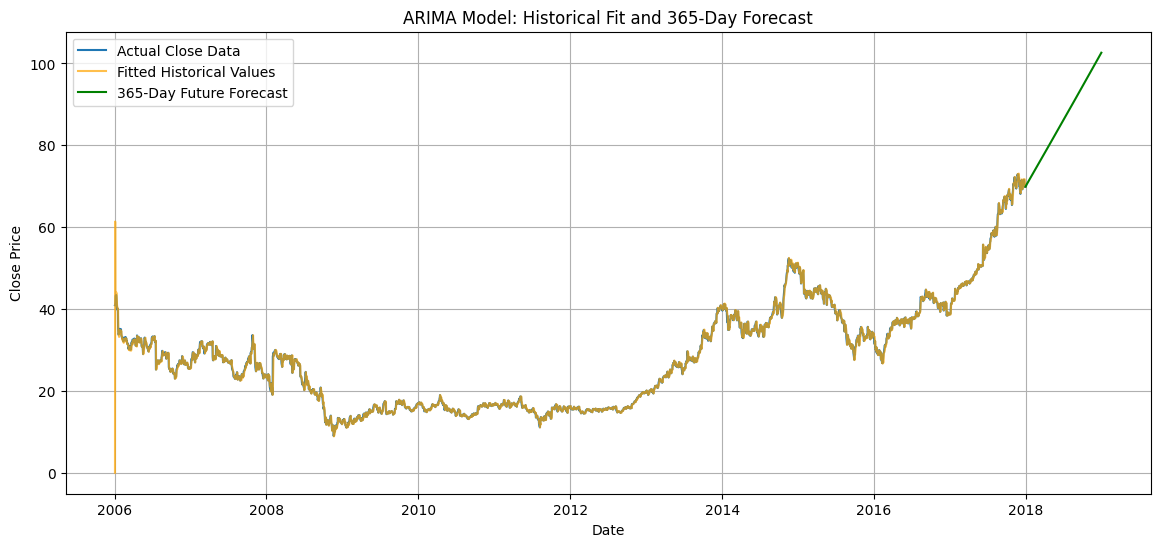

In [4]:
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Preparation & Train-Test Split
# ---------------------------------------------------------
# Ensure we are only working with non-null values to avoid series size mismatch errors
ts_data = df['Close'].dropna()

# Split: All data except the last 90 days for training, last 90 days for testing
train = ts_data.iloc[:-90]
test = ts_data.iloc[-90:]

print(f"Training data size: {len(train)} days")
print(f"Testing data size: {len(test)} days")

# ---------------------------------------------------------
# 2. Auto ARIMA Selection
# ---------------------------------------------------------
print("\nRunning auto_arima to find the optimal model parameters...")
# auto_arima searches for the best (p,d,q) parameters based on AIC
best_model = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=10, max_q=10,
    seasonal=False,         # Change to True and provide 'm' if data has strong seasonality
    stepwise=True,          # Uses efficient search algorithm
    suppress_warnings=True,
    error_action="ignore",
    trace=True              # Prints out the parameter search process
)

print(f"\nOptimal Model Found:\n{best_model.summary()}")

# ---------------------------------------------------------
# 3. Refitting on Full Data
# ---------------------------------------------------------
# Extract the best hyperparameters discovered on the training set
best_order = best_model.order
best_seasonal_order = best_model.seasonal_order

print(f"\nRefitting the best model (Order: {best_order}) on the full historical dataset...")
# Initialize a new ARIMA model with the best parameters and fit it to the full dataset
full_model = pm.ARIMA(order=best_order, seasonal_order=best_seasonal_order)
full_model.fit(ts_data)

# ---------------------------------------------------------
# 4. In-Sample Calculation and Future Forecasting
# ---------------------------------------------------------
# Calculate the fitted values for the entire historical dataset
historical_fitted_values = full_model.predict_in_sample()

# Forecast an additional 365 days into the future
forecast_horizon = 365
future_forecast = full_model.predict(n_periods=forecast_horizon)

# Generate future dates for the 365-day forecast
last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')
future_forecast.index = future_dates

# ---------------------------------------------------------
# 5. Optional: Combine and Visualize Results
# ---------------------------------------------------------
# Combine historical and forecasted values into a single DataFrame for easy exporting/viewing
results_df = pd.DataFrame({
    'Actual_Close': ts_data,
    'Model_Fitted': historical_fitted_values
})
forecast_df = pd.DataFrame({
    'Future_Forecast': future_forecast
})

# Display the head of the future forecast
print("\nFirst 5 days of the 365-day forecast:")
print(forecast_df.head())

# Plotting the results
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data, label='Actual Close Data')
plt.plot(ts_data.index, historical_fitted_values, label='Fitted Historical Values', color='orange', alpha=0.7)
plt.plot(future_forecast.index, future_forecast, label='365-Day Future Forecast', color='green')
plt.title('ARIMA Model: Historical Fit and 365-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

Running tweaked auto_arima...
Optimal Model Found: Order (4, 2, 1), Seasonal (2, 0, 0, 7)


/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given

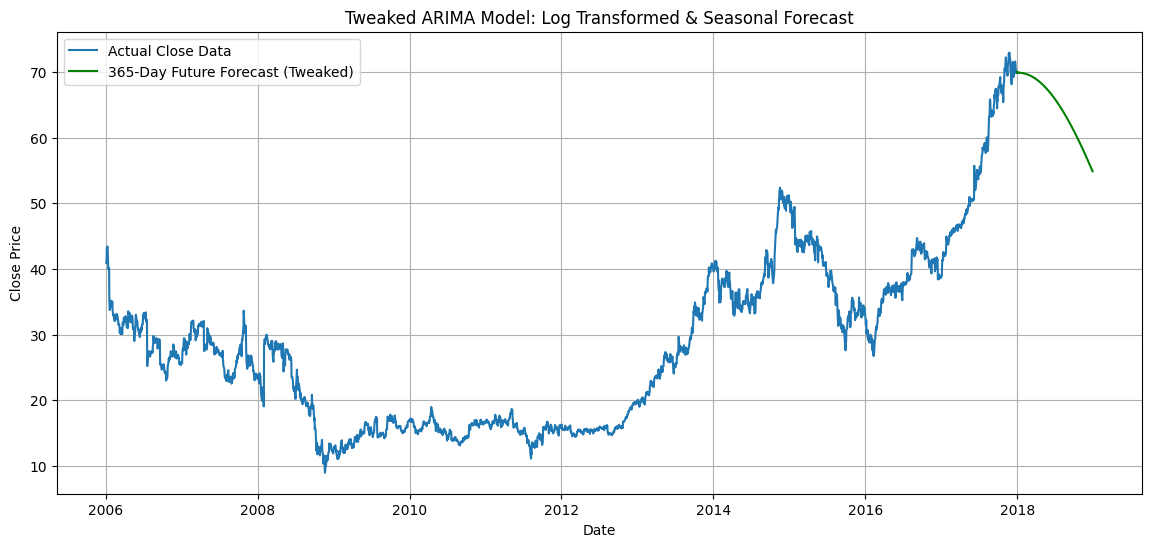

In [ ]:
import pandas as pd
import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Preparation & Log Transformation
# ---------------------------------------------------------
# Drop nulls to prevent series size mismatch issues
ts_data = df['Close'].dropna()

# Apply log transform to stabilize compounding variance
ts_log = np.log(ts_data)

# Split the logged data
train_log = ts_log.iloc[:-90]
test_log = ts_log.iloc[-90:]

# ---------------------------------------------------------
# 2. Tweaked Auto ARIMA Selection
# ---------------------------------------------------------
print("Running tweaked auto_arima...")
best_model = pm.auto_arima(
    train_log,
    start_p=0, start_q=0,
    max_p=15, max_q=15,
    seasonal=True, m=7,     # Assuming weekly seasonality (change to 30 for monthly)
    # trend='n',              # Forces the model to ignore deterministic downward/upward drift
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

print(f"Optimal Model Found: Order {best_model.order}, Seasonal {best_model.seasonal_order}")

# ---------------------------------------------------------
# 3. Refitting & Forecasting
# ---------------------------------------------------------
full_model = pm.ARIMA(order=best_model.order, seasonal_order=best_model.seasonal_order)
full_model.fit(ts_log)

# Forecast 365 days
forecast_horizon = 365
log_forecast = full_model.predict(n_periods=forecast_horizon)

# ---------------------------------------------------------
# 4. Inverse Transform and Format Dates
# ---------------------------------------------------------
# Convert log predictions back to original scale using exponential
x = np.exp(log_forecast)

last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')
future_forecast.index = future_dates

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data, label='Actual Close Data')
plt.plot(future_forecast.index, future_forecast, label='365-Day Future Forecast (Tweaked)', color='green')
plt.title('Tweaked ARIMA Model: Log Transformed & Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

21:55:51 - cmdstanpy - INFO - Chain [1] start processing
21:55:52 - cmdstanpy - INFO - Chain [1] done processing


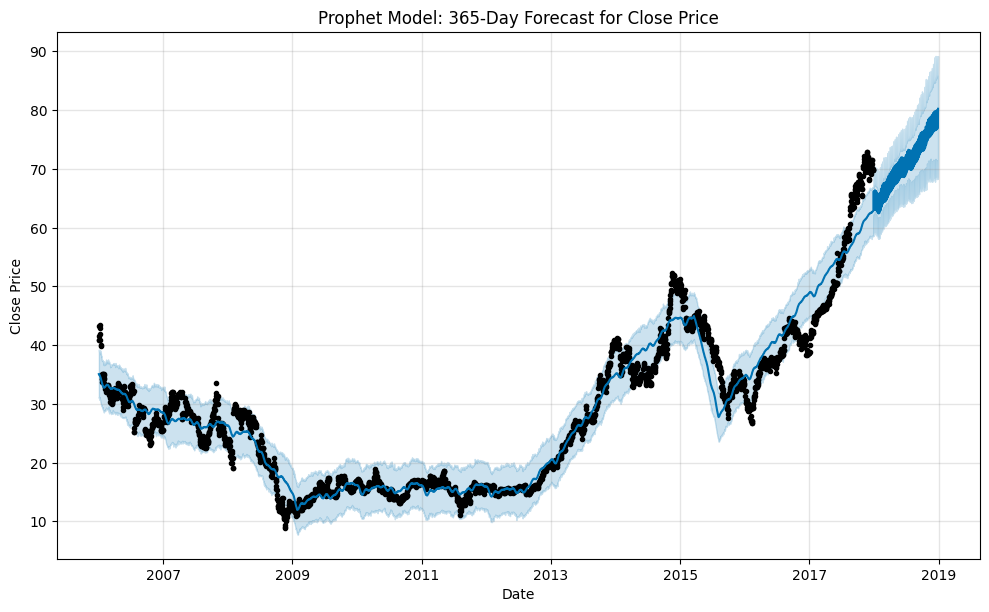

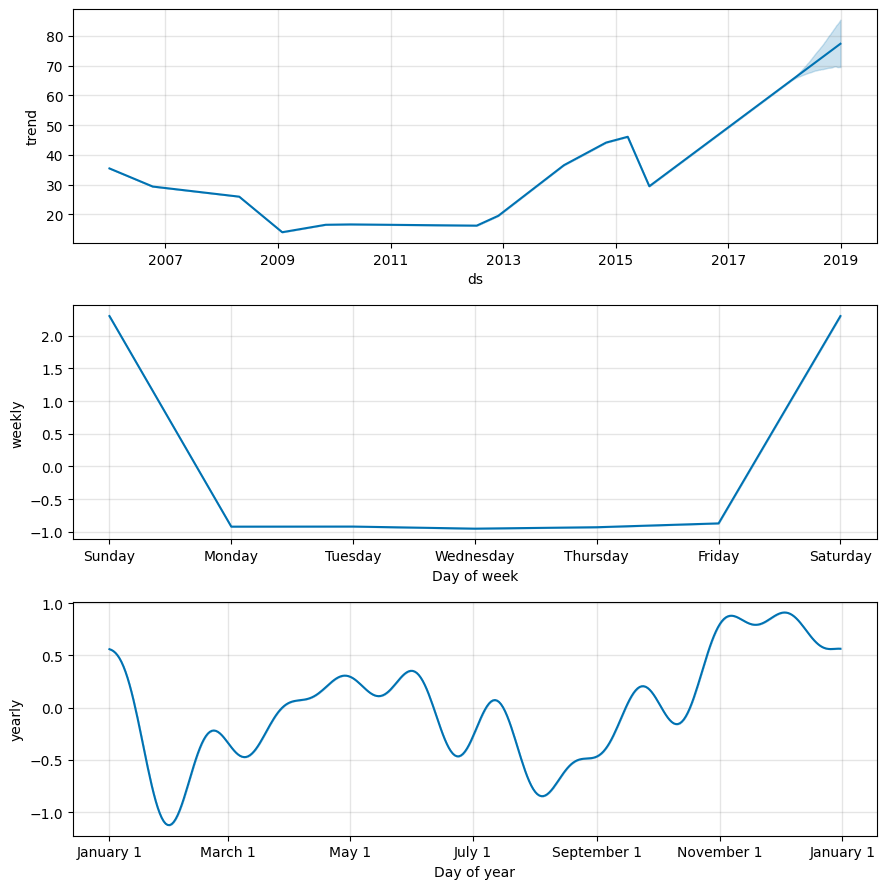

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
# 1. Prepare data for Prophet (Requires columns specifically named 'ds' and 'y')
# Assuming ts_data is your Series with a DatetimeIndex from the previous code
prophet_df = ts_data.reset_index()
prophet_df.columns = ['ds', 'y']

# 2. Initialize and fit the Prophet model
# You can toggle yearly/weekly seasonality based on your specific asset's behavior
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False,
    changepoint_prior_scale=0.05 # Increase this if the model isn't catching trend changes fast enough
)
model.fit(prophet_df)

# 3. Create a future dataframe for the 365-day horizon
future = model.make_future_dataframe(periods=365, freq='D')

# 4. Predict
forecast = model.predict(future)

# 5. Visualize (Prophet has built-in plotting)
fig1 = model.plot(forecast)
plt.title('Prophet Model: 365-Day Forecast for Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# Optional: View the individual trend and seasonality components
fig2 = model.plot_components(forecast)
plt.show()

In [14]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3379,2018-12-25,77.231112,68.313097,85.694238,69.563734,85.122324,-0.358068,-0.358068,-0.358068,-0.921343,-0.921343,-0.921343,0.563275,0.563275,0.563275,0.0,0.0,0.0,76.873043
3380,2018-12-26,77.269754,68.677303,86.032297,69.569878,85.243902,-0.391768,-0.391768,-0.391768,-0.953319,-0.953319,-0.953319,0.561550,0.561550,0.561550,0.0,0.0,0.0,76.877986
3381,2018-12-27,77.308397,68.396284,85.886061,69.576434,85.340414,-0.369944,-0.369944,-0.369944,-0.931467,-0.931467,-0.931467,0.561523,0.561523,0.561523,0.0,0.0,0.0,76.938453
3382,2018-12-28,77.347040,68.459661,86.244008,69.584992,85.424252,-0.310229,-0.310229,-0.310229,-0.872812,-0.872812,-0.872812,0.562583,0.562583,0.562583,0.0,0.0,0.0,77.036811
3383,2018-12-29,77.385683,70.820463,89.220335,69.595266,85.504943,2.864799,2.864799,2.864799,2.300779,2.300779,2.300779,0.564020,0.564020,0.564020,0.0,0.0,0.0,80.250482


## More options 

/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training Model 1: Tweaked ARIMA...


21:04:23 - cmdstanpy - INFO - Chain [1] start processing


Training Model 2: Prophet...


21:04:23 - cmdstanpy - INFO - Chain [1] done processing


Training Model 3: XGBoost...
Training Model 4: Exponential Smoothing...

MAPE COMPARISON ON 90-DAY TEST SET
Exp Smoothing       : 2.39%
XGBoost             : 9.14%
Prophet             : 28.99%
Tweaked ARIMA       : 140.33%


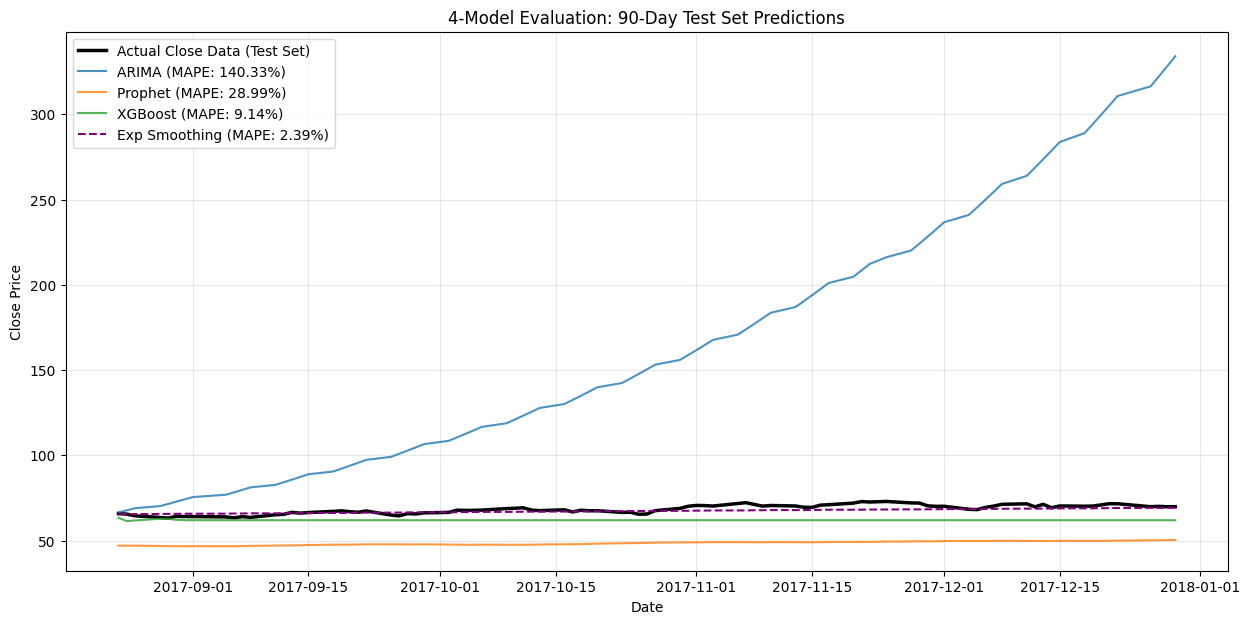

In [8]:
import pandas as pd
import numpy as np
import pmdarima as pm
from prophet import Prophet
import xgboost as xgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. Data Preparation & Helper Functions
# ---------------------------------------------------------
# Ensure no nulls in the time series
ts_data = df['Close'].dropna()

# Standard split for time series models
train = ts_data.iloc[:-90]
test = ts_data.iloc[-90:]

# Helper function to format MAPE as a percentage
def get_mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

# Dictionary to store the results
mape_results = {}

# ---------------------------------------------------------
# 2. Model 1: Tweaked Auto ARIMA (Log + Seasonal)
# ---------------------------------------------------------
print("Training Model 1: Tweaked ARIMA...")
train_log = np.log(train)

arima_model = pm.auto_arima(
    train_log,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True, m=7, 
              
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

log_forecast = arima_model.predict(n_periods=90)
arima_test_predictions = np.exp(log_forecast)

mape_results['Tweaked ARIMA'] = get_mape(test, arima_test_predictions)

# ---------------------------------------------------------
# 3. Model 2: Meta Prophet
# ---------------------------------------------------------
print("Training Model 2: Prophet...")
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

prophet_test_dates = pd.DataFrame({'ds': test.index})
prophet_forecast = prophet_model.predict(prophet_test_dates)
prophet_test_predictions = prophet_forecast['yhat'].values

mape_results['Prophet'] = get_mape(test, prophet_test_predictions)

# ---------------------------------------------------------
# 4. Model 3: XGBoost (Tree-Based with 30-Day Lags)
# ---------------------------------------------------------
print("Training Model 3: XGBoost...")
def create_lagged_features(data, lags):
    df_lags = pd.DataFrame(data)
    for lag in range(1, lags + 1):
        df_lags[f'lag_{lag}'] = df_lags['Close'].shift(lag)
    return df_lags

num_lags = 30
df_features = create_lagged_features(ts_data, num_lags).dropna()

X = df_features.drop('Close', axis=1)
y = df_features['Close']

X_train, X_test = X.iloc[:-90], X.iloc[-90:]
y_train, y_test = y.iloc[:-90], y.iloc[-90:]

xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, objective='reg:squarederror')
xgb_model.fit(X_train, y_train, verbose=False)

xgb_test_predictions = xgb_model.predict(X_test)

mape_results['XGBoost'] = get_mape(y_test, xgb_test_predictions)

# ---------------------------------------------------------
# 5. Model 4: Exponential Smoothing (Holt-Winters)
# ---------------------------------------------------------
print("Training Model 4: Exponential Smoothing...")
# Using additive trend and seasonality (assuming a weekly 7-day cycle)
hw_model = ExponentialSmoothing(
    train, 
    trend='add', 
    seasonal='add', 
    seasonal_periods=5,
    initialization_method="estimated"
).fit()

# Forecast 90 steps ahead
hw_test_predictions = hw_model.forecast(90)

mape_results['Exp Smoothing'] = get_mape(test, hw_test_predictions)

# ---------------------------------------------------------
# 6. Output Comparison and Plotting
# ---------------------------------------------------------
print("\n" + "="*45)
print("MAPE COMPARISON ON 90-DAY TEST SET")
print("="*45)
for model_name, mape_val in sorted(mape_results.items(), key=lambda item: item[1]):
    print(f"{model_name:<20}: {mape_val:.2f}%")
print("="*45)

# Plot the test set predictions against actuals
plt.figure(figsize=(15, 7))
plt.plot(test.index, test.values, label='Actual Close Data (Test Set)', color='black', linewidth=2.5)

plt.plot(test.index, arima_test_predictions, label=f'ARIMA (MAPE: {mape_results["Tweaked ARIMA"]:.2f}%)', alpha=0.8)
plt.plot(test.index, prophet_test_predictions, label=f'Prophet (MAPE: {mape_results["Prophet"]:.2f}%)', alpha=0.8)
plt.plot(y_test.index, xgb_test_predictions, label=f'XGBoost (MAPE: {mape_results["XGBoost"]:.2f}%)', alpha=0.8)
plt.plot(test.index, hw_test_predictions, label=f'Exp Smoothing (MAPE: {mape_results["Exp Smoothing"]:.2f}%)', linestyle='--', color='purple')

plt.title('4-Model Evaluation: 90-Day Test Set Predictions')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

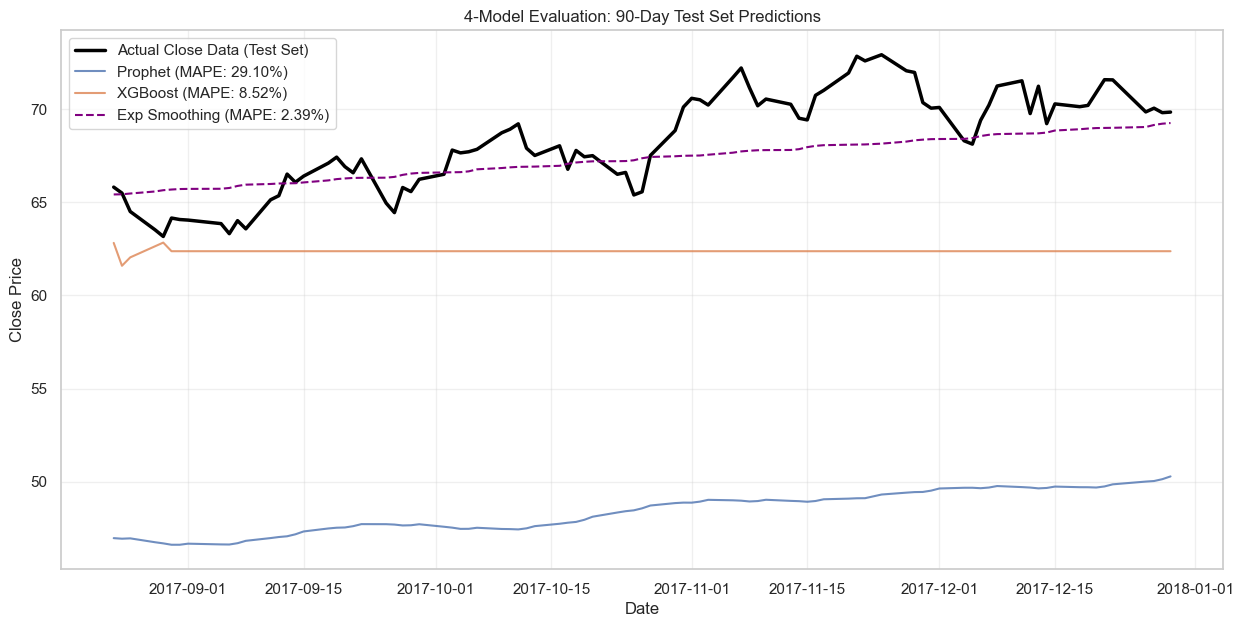

In [37]:

# Plot the test set predictions against actuals
plt.figure(figsize=(15, 7))
plt.plot(test.index, test.values, label='Actual Close Data (Test Set)', color='black', linewidth=2.5)

# plt.plot(test.index, arima_test_predictions, label=f'ARIMA (MAPE: {mape_results["Tweaked ARIMA"]:.2f}%)', alpha=0.8)
plt.plot(test.index, prophet_test_predictions, label=f'Prophet (MAPE: {mape_results["Prophet"]:.2f}%)', alpha=0.8)
plt.plot(y_test.index, xgb_test_predictions, label=f'XGBoost (MAPE: {mape_results["XGBoost"]:.2f}%)', alpha=0.8)
plt.plot(test.index, hw_test_predictions, label=f'Exp Smoothing (MAPE: {mape_results["Exp Smoothing"]:.2f}%)', linestyle='--', color='purple')

plt.title('4-Model Evaluation: 90-Day Test Set Predictions')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()